In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, TargetEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('../data/raw/ecommerce_customer_churn_dataset.csv')
df['missing_flag'] = df.isna().any(axis=1).astype(int)

In [3]:
X = df.drop('Churned', axis=1)
y = df['Churned']

Xtrain, Xrest, ytrain, yrest = train_test_split(
    X, y, train_size=0.7, stratify=y, random_state=42
)

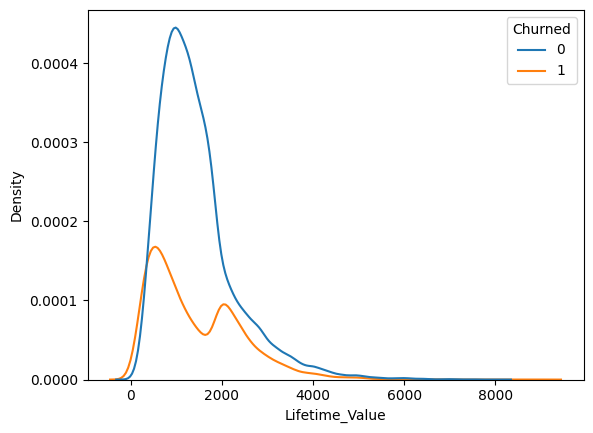

In [4]:
sns.kdeplot(df, x='Lifetime_Value', hue='Churned')
plt.show()

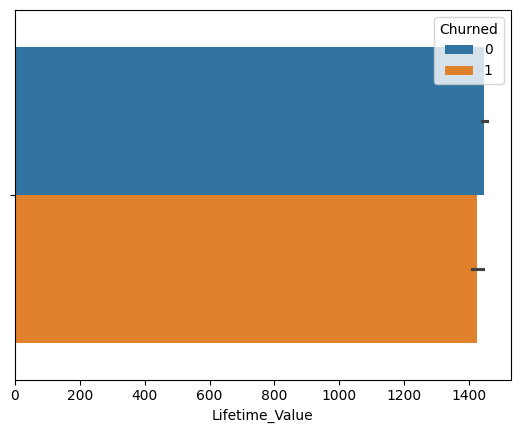

In [5]:
sns.barplot(df, x='Lifetime_Value', hue='Churned')
plt.show()

### check for multicollinearity


In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# floats are all the numeric cols
num_cols = X.dropna().select_dtypes(float).columns
vif_data = [variance_inflation_factor(X.dropna().select_dtypes(float).values, i) for i in range(num_cols.size)]
vif = pd.DataFrame({
    'feature': num_cols,
    'VIF': vif_data
})

In [7]:
vif.sort_values('VIF')

,feature,VIF
8,Average_Order_Value,1.580026
9,Days_Since_Last_Purchase,1.997038
11,Returns_Rate,2.611092
1,Membership_Years,3.053466
14,Product_Reviews_Written,4.670723
10,Discount_Usage_Rate,4.715345
17,Payment_Method_Diversity,5.277947
19,Credit_Balance,6.133862
13,Customer_Service_Calls,6.135915
6,Wishlist_Items,6.438491


The last 2 (`Session_Duration_Avg` and `Pages_Per_Session`) appears on higher end of multicolinearity, which would correlate in an ecom. 
* More pages per session → longer session duration

* Longer session duration → more pages viewed

For now all columns are used for baseline, later will experiment with dropping and/or combining them.

### impute numeric missing 

In [8]:
num_cols = Xtrain.select_dtypes(float).columns

In [9]:
mean_imputer = SimpleImputer().set_output(transform='pandas')

In [10]:
mean_imputer.fit(Xtrain[num_cols])

SimpleImputer()

In [11]:
Xtrain_missing_flag = Xtrain.isna().any()
Xtrain_missing_fix = mean_imputer.transform(Xtrain[num_cols])
Xtrain = Xtrain.combine_first(Xtrain_missing_fix)

### encoding categorical columns

In [12]:
Xtrain.select_dtypes('O').head()

,City,Country,Gender,Signup_Quarter
168,London,UK,Male,Q3
4178,Los Angeles,USA,Male,Q1
40124,Birmingham,UK,Female,Q4
43650,Tokyo,Japan,Male,Q1
20514,Manchester,UK,Male,Q1


In [13]:
Xtrain.select_dtypes('O').nunique()

City              40
Country            8
Gender             3
Signup_Quarter     4
dtype: int64

In [14]:
for col in Xtrain.select_dtypes('O').columns:
    print(f"{col}: {Xtrain[col].unique()}")

City: ['London' 'Los Angeles' 'Birmingham' 'Tokyo' 'Manchester' 'Lyon' 'Houston'
 'Toulouse' 'Brisbane' 'Phoenix' 'Bangalore' 'Munich' 'Leeds' 'New York'
 'Calgary' 'Vancouver' 'Perth' 'Marseille' 'Chicago' 'Frankfurt' 'Mumbai'
 'Nice' 'Berlin' 'Glasgow' 'Delhi' 'Montreal' 'Melbourne' 'Paris'
 'Cologne' 'Toronto' 'Sydney' 'Ottawa' 'Yokohama' 'Kyoto' 'Nagoya'
 'Hyderabad' 'Hamburg' 'Adelaide' 'Osaka' 'Chennai']
Country: ['UK' 'USA' 'Japan' 'France' 'Australia' 'India' 'Germany' 'Canada']
Gender: ['Male' 'Female' 'Other']
Signup_Quarter: ['Q3' 'Q1' 'Q4' 'Q2']


In [15]:
low_cardinal_cols = ['Gender', 'Signup_Quarter', 'Country']
mid_cardinal_cols = ['City']

#### low cardinality variables

In [16]:
ohe = OneHotEncoder(sparse_output=False, drop='first', dtype=np.uint8, handle_unknown='error').set_output(transform='pandas')
ohe.fit(Xtrain[low_cardinal_cols])

Xtrain_lowcard_ = ohe.transform(Xtrain[low_cardinal_cols])
Xtrain = pd.concat([Xtrain, Xtrain_lowcard_], axis=1).drop(low_cardinal_cols, axis=1)

#### moderate/mid cardinality variable

In [17]:
[X[col].value_counts().values for col in mid_cardinal_cols]

[array([3549, 3490, 3477, 3475, 3393, 1576, 1535, 1529, 1458, 1436, 1247,
        1209, 1204, 1182, 1181, 1033, 1026, 1013,  960,  893,  830,  828,
         817,  817,  815,  805,  799,  794,  793,  776,  736,  698,  694,
         693,  691,  537,  514,  507,  496,  494])]

City acts like a subcategory with Country as main category. Performing one-hot encoding on city aswell will be a dimensionality curse and multicolinearity issue.

From eda, these categorical variables show little-to-no direct relation with target variable (`Churned`). 

In [18]:
# Frequency encoding for City
freq_map = Xtrain[mid_cardinal_cols].value_counts(normalize=True)
Xtrain[mid_cardinal_cols] = Xtrain[mid_cardinal_cols].replace(freq_map)

In [19]:
Xtrain.dtypes.value_counts()

float64    21
uint8      12
int64       1
Name: count, dtype: int64

### train model

In [20]:
lr = LogisticRegression()
lr.fit(Xtrain, ytrain)

LogisticRegression()

### evaluate model

In [21]:
# impute missing values
Xrest_missing_flag = Xrest.isna().any(axis=1)
Xrest_missing_fix = mean_imputer.transform(Xrest[num_cols])
Xrest = Xrest.combine_first(Xrest_missing_fix)

In [22]:
# low cardinal features
Xrest_lowcard_ = ohe.transform(Xrest[low_cardinal_cols])
Xrest = pd.concat([Xrest, Xrest_lowcard_], axis=1).drop(low_cardinal_cols, axis=1)

In [23]:
# mid cardinal features
Xrest[mid_cardinal_cols] = Xrest[mid_cardinal_cols].replace(freq_map)

In [24]:
lr.score(Xrest, yrest)

0.7694

In [25]:
lr.score(Xrest[~Xrest_missing_flag], yrest[~Xrest_missing_flag])

0.7775721687638786